In [171]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
from glob import glob

In [ ]:
dataset_root_path = "/home/mazhar-endolitk/Work/twin-seeker/datasets/imdb_crop/" #path to contents of imdb_crop_folder

In [3]:
image_paths = glob('/home/mazhar-endolitk/Work/twin-seeker/datasets/imdb_crop/0*/*.jpg')
len(image_paths)


# image_paths = glob('/home/mazhar-endolitk/Work/twin-seeker/datasets/imdb/0*/*.jpg')
# len(image_paths)

46641

In [172]:
import scipy.io

# Load .mat file
imdb_dataset = scipy.io.loadmat('../datasets/imdb_crop/imdb.mat')

In [46]:
imdb_dataset.keys()

dict_keys(['__header__', '__version__', '__globals__', 'imdb'])

In [47]:
imdb_dataset['__header__']

b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Jan 17 11:30:27 2016'

In [48]:
imdb_dataset['__version__']

'1.0'

In [49]:
imdb_dataset["__globals__"]

[]

In [50]:
type(imdb_dataset['imdb'])

numpy.ndarray

In [51]:
imdb_dataset['imdb']['full_path'][0][0][0].shape

(460723,)

----
-----
# Data Cleaning

#### Move data to a dict for easy access

In [62]:
content_keys = [
    "dob",
    "photo_taken",
    "full_path",
    "gender",
    "name",
    "face_location",
    "face_score",
    "second_face_score",
    "celeb_names",
    "celeb_id"
]
for key in content_keys:
    print(key, imdb_dataset['imdb'][key][0][0][0].shape)
print("-"*100)

dataset = {
    key: imdb_dataset['imdb'][key][0][0][0]
    for key in content_keys
}

dataset

dob (460723,)
photo_taken (460723,)
full_path (460723,)
gender (460723,)
name (460723,)
face_location (460723,)
face_score (460723,)
second_face_score (460723,)
celeb_names (20284,)
celeb_id (460723,)
----------------------------------------------------------------------------------------------------


{'dob': array([693726, 693726, 693726, ..., 726831, 726831, 726831], dtype=int32),
 'photo_taken': array([1968, 1970, 1968, ..., 2011, 2011, 2011], dtype=uint16),
 'full_path': array([array(['01/nm0000001_rm124825600_1899-5-10_1968.jpg'], dtype='<U43'),
        array(['01/nm0000001_rm3343756032_1899-5-10_1970.jpg'], dtype='<U44'),
        array(['01/nm0000001_rm577153792_1899-5-10_1968.jpg'], dtype='<U43'),
        ...,
        array(['08/nm3994408_rm926592512_1989-12-29_2011.jpg'], dtype='<U44'),
        array(['08/nm3994408_rm943369728_1989-12-29_2011.jpg'], dtype='<U44'),
        array(['08/nm3994408_rm976924160_1989-12-29_2011.jpg'], dtype='<U44')],
       dtype=object),
 'gender': array([1., 1., 1., ..., 0., 0., 0.]),
 'name': array([array(['Fred Astaire'], dtype='<U12'),
        array(['Fred Astaire'], dtype='<U12'),
        array(['Fred Astaire'], dtype='<U12'), ...,
        array(['Jane Levy'], dtype='<U9'),
        array(['Jane Levy'], dtype='<U9'),
        array(['Jane Levy']

In [63]:
dataset['dob']

array([693726, 693726, 693726, ..., 726831, 726831, 726831], dtype=int32)

In [168]:
def dob_from_matlab_serial_date_number(matlab_datenum:int)->str:
    """Get date of birth from matlab serial date number.
    Args:
    -----
        matlab_datenum (int): Matlab serial date number.
        
    Returns:
    -------
        str: YYYY/MM/DD (Date of birth).
    """
    import datetime
    
    # Define the start date
    start_date = datetime.datetime(1, 1, 1)

    # Convert the Matlab serial date number to a datetime object
    date = start_date + datetime.timedelta(days=matlab_datenum - 1)

    return "/".join([str(i) for i in [date.year, date.month, date.day]])

In [170]:
import os.path as osp

In [79]:
dataset["full_path"][0].item()

'01/nm0000001_rm124825600_1899-5-10_1968.jpg'

In [82]:
def check_image_exists(image_path:str)->bool:
    """Check if image exists.
    Args:
    -----
        image_path (str): Image path.
        
    Returns:
    -------
        bool: True if image exists, False otherwise.
    """
    return osp.exists(osp.join(dataset_root_path, image_path))

from tqdm import tqdm

for i in tqdm(range(len(dataset["full_path"]))):
    image_path = dataset["full_path"][i].item()
    if not check_image_exists(image_path):
        print(image_path)

100%|██████████| 460723/460723 [00:01<00:00, 252826.53it/s]


In [84]:
osp.join(dataset_root_path, dataset["full_path"][0].item())

'/home/mazhar-endolitk/Work/twin-seeker/datasets/imdb_crop/01/nm0000001_rm124825600_1899-5-10_1968.jpg'

Full Path: 01/nm0000001_rm980463616_1899-5-10_1968.jpg


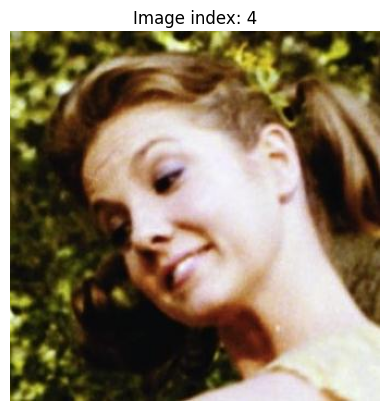

(340, 340, 3)
DOB: 1900/5/11
Photo Taken: 1968
Gender: 1.0
Name: Fred Astaire
Celeb ID: 6488


In [169]:
def explore_image(idx:int):
    """Explore image.
    Args:
    -----
        idx (int): Image index.
    """
    # Face full_path
    full_path = dataset["full_path"][idx].item()
    print("Full Path:", full_path)


    # View Image
    image_path = dataset["full_path"][idx].item()
    image = Image.open(osp.join(dataset_root_path, image_path))
    # ipd.display(image)
    plt.imshow(image)
    plt.title(f"Image index: {idx}")
    plt.axis("off")
    plt.show()

    # View Image Dimensions
    print(np.array(image).shape)

    # View Date of Birth
    dob = dataset["dob"][idx].item()
    dob = dob_from_matlab_serial_date_number(dob)
    print("DOB:", dob)


    # Photo Taken
    photo_taken = dataset["photo_taken"][idx].item()
    print("Photo Taken:", photo_taken)

    # Gender
    gender = dataset["gender"][idx].item()
    print("Gender:", gender)

    # Name
    name = dataset["name"][idx].item()
    print("Name:", name)

    # Celeb ID:
    celeb_id = dataset["celeb_id"][idx].item()
    print("Celeb ID:", celeb_id) 
explore_image(4)

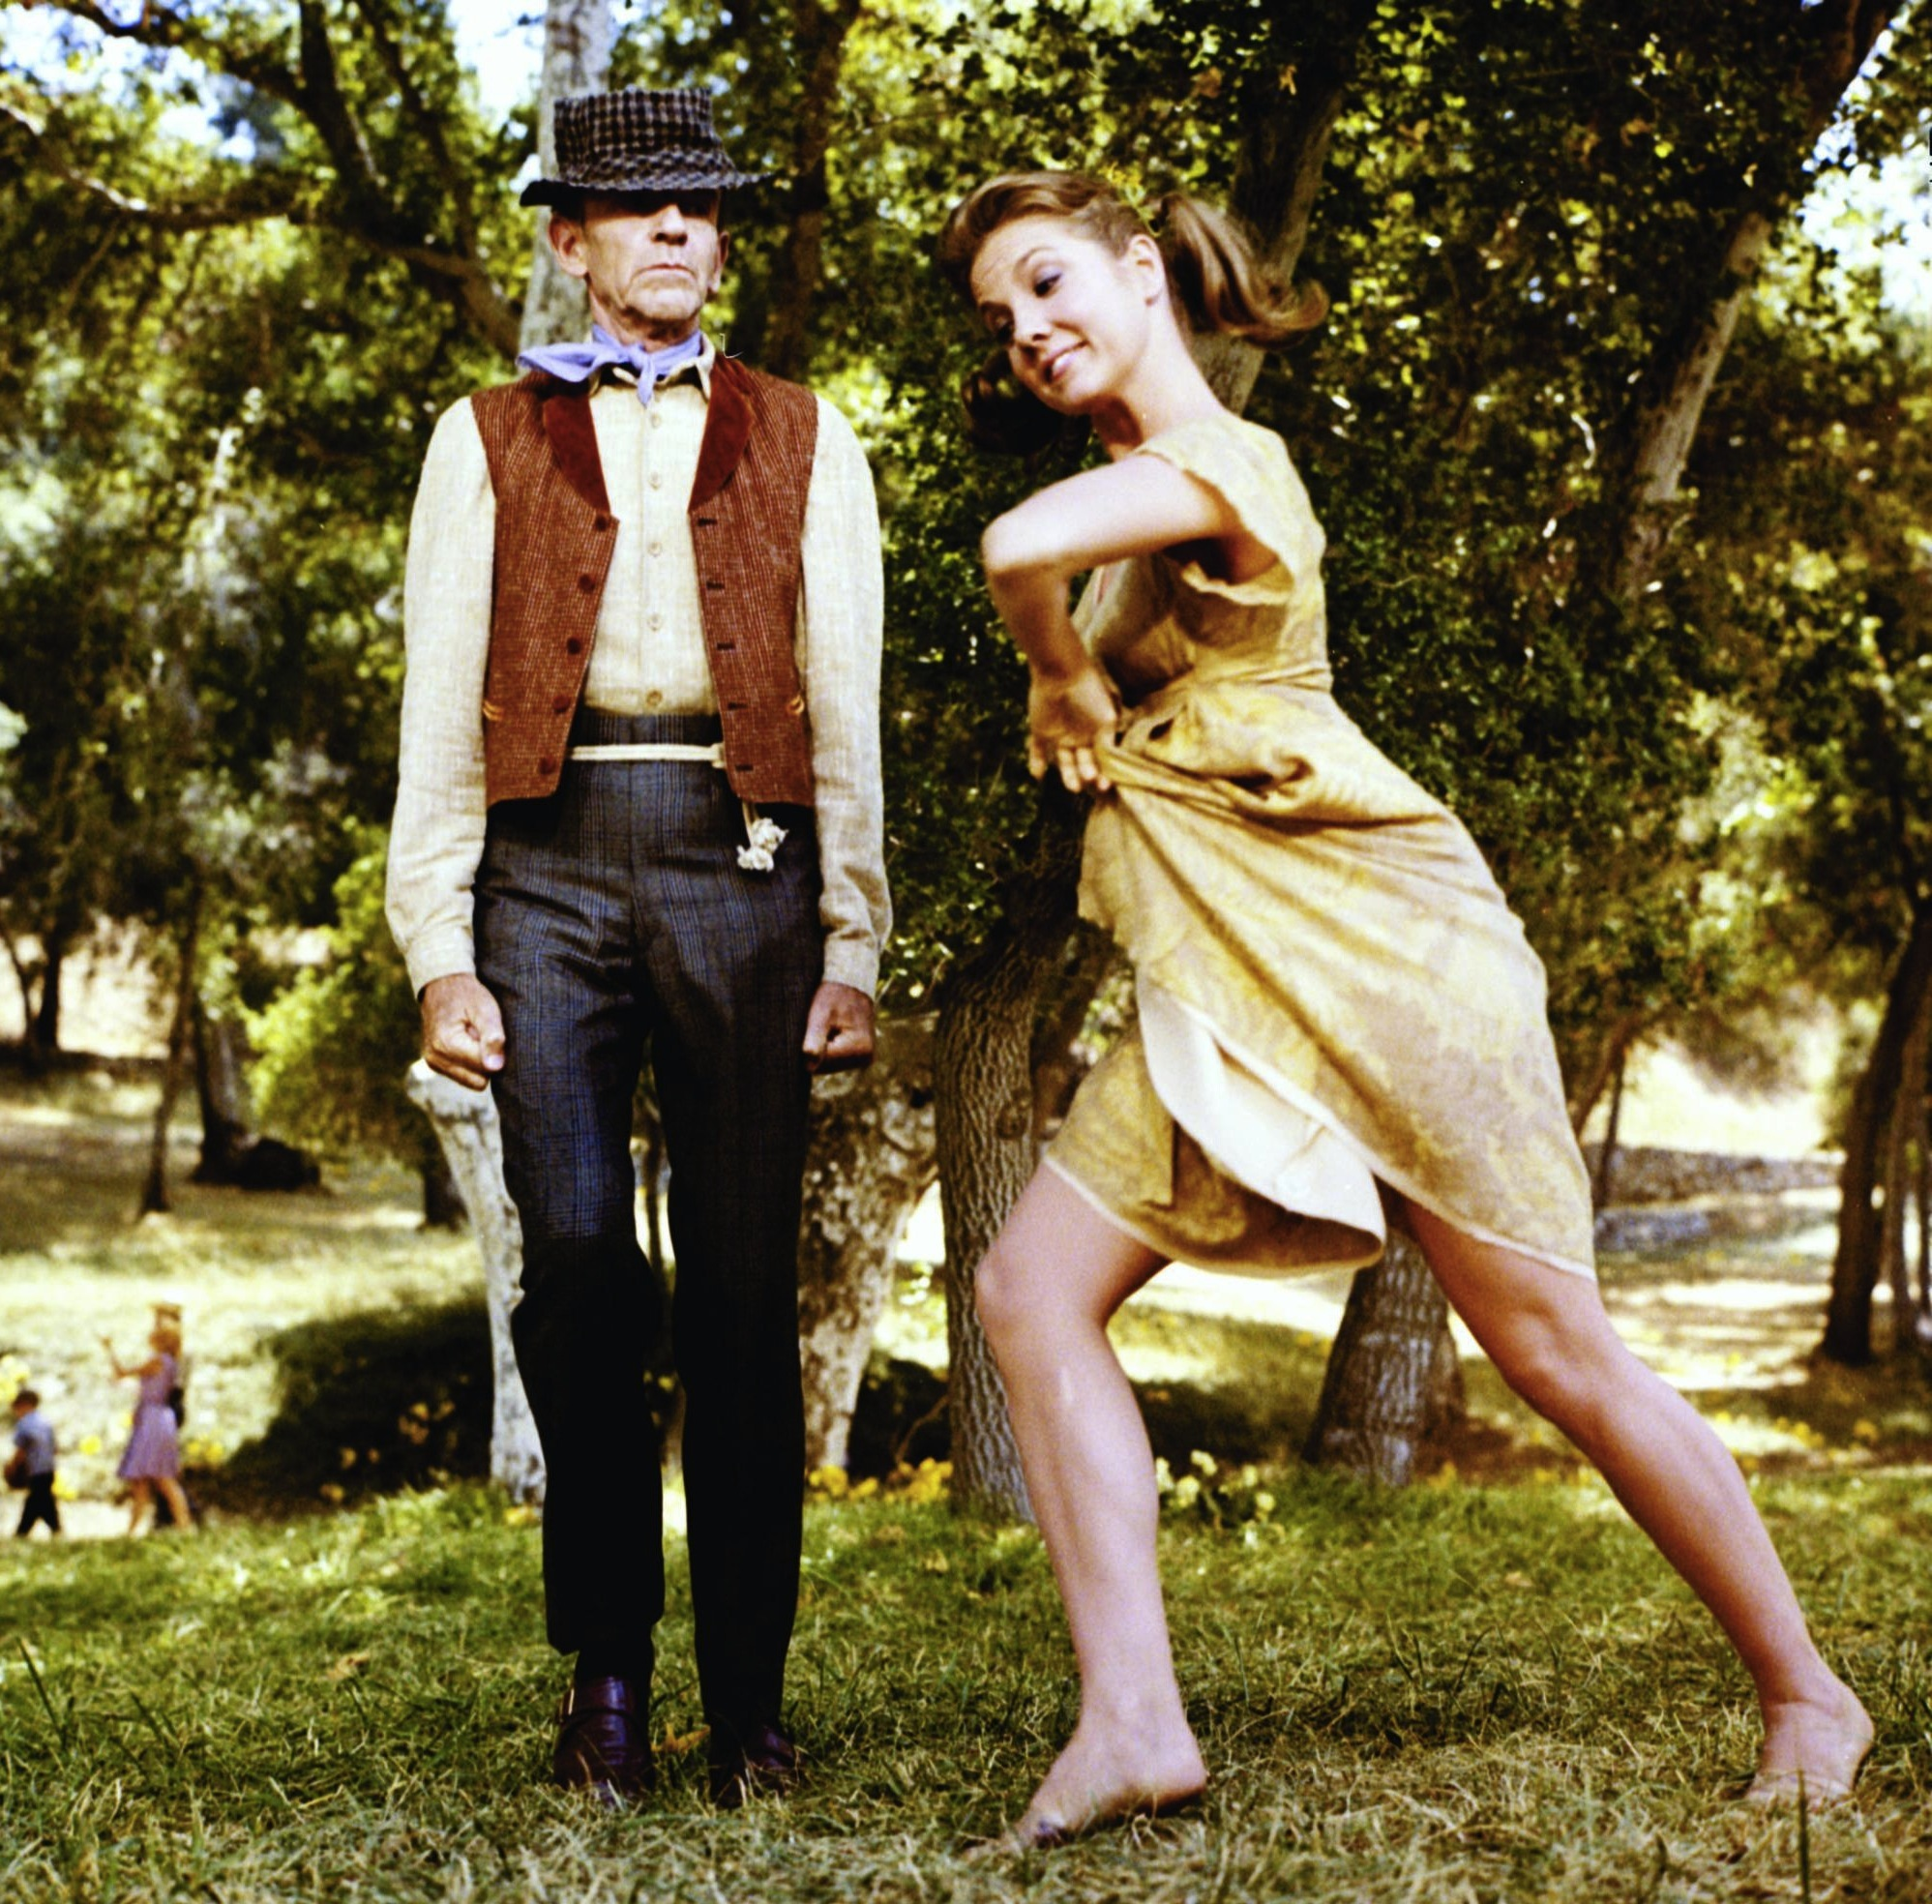

In [162]:
Image.open(osp.join("/home/mazhar-endolitk/Work/twin-seeker/datasets/imdb/", dataset["full_path"][4].item()))